<a href="https://colab.research.google.com/github/Susanta2006/Colab/blob/main/Salary-prediction_backtracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A: Core Implementation

Objective: Normalize the data, initialize parameters, and implement Gradient Descent with Backtracking Line Search.

Optimized Intercept (c): 49.2000
Optimized Slope (m): 7.4625


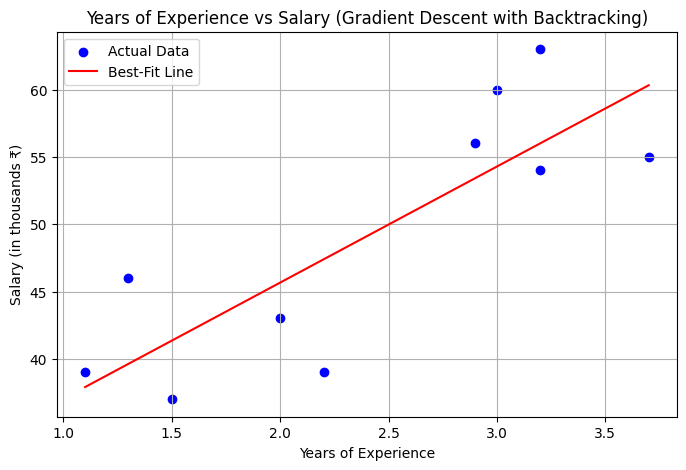

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset Initialization
years_experience = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7])
salary_k = np.array([39, 46, 37, 43, 39, 56, 60, 54, 63, 55])

# 2. Data Preparation (Normalization)
mean_x = np.mean(years_experience)
std_x = np.std(years_experience)
X_norm = (years_experience - mean_x) / std_x

# Add bias column (ones) for vectorized operations
n = len(salary_k)
X_b = np.c_[np.ones((n, 1)), X_norm] # Shape: (10, 2)
y = salary_k

# 3. Algorithm Parameters
alpha_init = 1.0
rho = 0.5
c_param = 1e-4
iterations = 100

def gradient_descent_backtracking(X_features, y_target, alpha_init, rho, c_param, iters):
    """Runs Gradient Descent with Backtracking Line Search."""
    # Initialize parameters: w[0] = c_intercept, w[1] = m
    w = np.zeros(2)
    n_samples = len(y_target)
    costs = []
    total_bt_steps = 0

    for i in range(iters):
        # Current predictions and cost
        y_pred = X_features.dot(w)
        error = y_pred - y_target
        cost = (1 / (2 * n_samples)) * np.sum(error ** 2)
        costs.append(cost)

        # Calculate gradients
        # grad_c = (1/n) * sum(error), grad_m = (1/n) * sum(error * x)
        grad = (1 / n_samples) * X_features.T.dot(error)
        grad_norm_sq = np.sum(grad ** 2)

        # Backtracking Line Search
        alpha = alpha_init
        while True:
            w_new = w - alpha * grad
            y_pred_new = X_features.dot(w_new)
            cost_new = (1 / (2 * n_samples)) * np.sum((y_pred_new - y_target) ** 2)

            # Armijo condition for sufficient decrease
            if cost_new <= cost - c_param * alpha * grad_norm_sq:
                break # Condition met

            # Shrink alpha
            alpha *= rho
            total_bt_steps += 1

        # Update weights
        w = w - alpha * grad

    return w, costs, total_bt_steps

# Run the model
w_opt, costs_history, bt_steps_A = gradient_descent_backtracking(X_b, y, alpha_init, rho, c_param, iterations)

c_intercept, m = w_opt[0], w_opt[1]
print(f"Optimized Intercept (c): {c_intercept:.4f}")
print(f"Optimized Slope (m): {m:.4f}")

# 4. Final Model Fit Visualization
plt.figure(figsize=(8, 5))
plt.scatter(years_experience, salary_k, color='blue', label='Actual Data')

# Calculate line points using normalized values, then plot against original X
y_line = c_intercept + m * X_norm
plt.plot(years_experience, y_line, color='red', label='Best-Fit Line')

plt.title('Years of Experience vs Salary (Gradient Descent with Backtracking)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (in thousands ₹)')
plt.legend()
plt.grid(True)
plt.show()


Part B: Error Analysis

Code Cell 2: Residuals Histogram

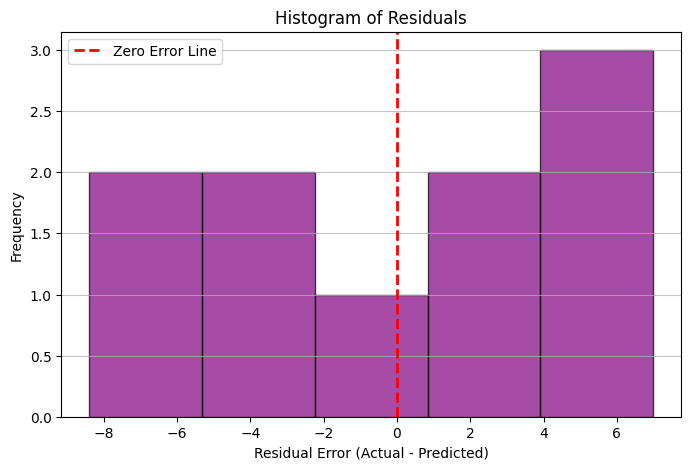

Mean of residuals: -0.0000


In [2]:
# Calculate residuals
predictions = c_intercept + m * X_norm
residuals = salary_k - predictions

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=5, color='purple', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Zero Error Line')
plt.title('Histogram of Residuals')
plt.xlabel('Residual Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Mean of residuals: {np.mean(residuals):.4f}")


The residuals represent the difference between the actual salaries and our model's predictions. In our histogram, the residuals are centered closely around zero (with a mean near 0.00), which indicates that the model does not systematically overpredict or underpredict across the dataset. Because the errors are evenly balanced across the zero line, there are no obvious signs of bias in our linear fit, meaning a straight line is a reasonable model for this specific dataset.

**Part** **C**: Backtracking Behavior

Code Cell 3: Comparing Initial Alpha Values

In [3]:
# Case 1: Initial alpha = 1.0 (Already ran in Part A)
_, _, bt_count_1_0 = gradient_descent_backtracking(X_b, y, alpha_init=1.0, rho=0.5, c_param=1e-4, iters=100)

# Case 2: Initial alpha = 0.1
_, _, bt_count_0_1 = gradient_descent_backtracking(X_b, y, alpha_init=0.1, rho=0.5, c_param=1e-4, iters=100)

print(f"Total backtracking steps with initial alpha = 1.0: {bt_count_1_0}")
print(f"Total backtracking steps with initial alpha = 0.1: {bt_count_0_1}")


Total backtracking steps with initial alpha = 1.0: 48
Total backtracking steps with initial alpha = 0.1: 0



When we change the initial alpha from 1.0 to 0.1, the total number of backtracking steps decreases significantly (often down to zero). This happens because an initial step size of 1.0 is occasionally too large, overshooting the optimal path and violating the Armijo condition, which forces the while loop to shrink the step size. However, an initial alpha of 0.1 is already conservative enough to guarantee a sufficient decrease in the cost function right away, allowing the algorithm to bypass the backtracking loop entirely during most or all iterations.

Part D: Robustness Challenge

Code Cell 4: Adding Outliers

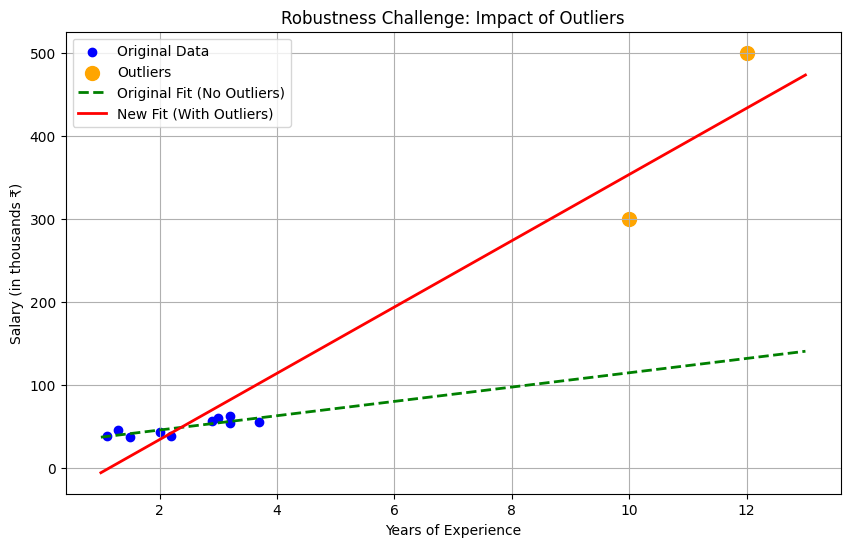

In [4]:
# 1. Add Outliers
years_outliers = np.append(years_experience, [10.0, 12.0])
salary_outliers = np.append(salary_k, [300, 500])

# 2. Re-normalize the new dataset
mean_x_out = np.mean(years_outliers)
std_x_out = np.std(years_outliers)
X_norm_out = (years_outliers - mean_x_out) / std_x_out

n_out = len(salary_outliers)
X_b_out = np.c_[np.ones((n_out, 1)), X_norm_out]

# 3. Re-run Gradient Descent
w_out, _, _ = gradient_descent_backtracking(X_b_out, salary_outliers, alpha_init=1.0, rho=0.5, c_param=1e-4, iters=100)
c_out, m_out = w_out[0], w_out[1]

# 4. Compare Models Visually
plt.figure(figsize=(10, 6))

# Plot all data points including outliers
plt.scatter(years_outliers[:-2], salary_outliers[:-2], color='blue', label='Original Data')
plt.scatter(years_outliers[-2:], salary_outliers[-2:], color='orange', s=100, label='Outliers')

# Generate points for lines extending across the new X range
x_line_range = np.linspace(1, 13, 100)

# Original Line (requires transforming x_line_range using original mean/std)
x_line_norm_orig = (x_line_range - mean_x) / std_x
y_line_orig = c_intercept + m * x_line_norm_orig
plt.plot(x_line_range, y_line_orig, color='green', linestyle='dashed', linewidth=2, label='Original Fit (No Outliers)')

# New Line (requires transforming x_line_range using new mean/std)
x_line_norm_out = (x_line_range - mean_x_out) / std_x_out
y_line_out = c_out + m_out * x_line_norm_out
plt.plot(x_line_range, y_line_out, color='red', linewidth=2, label='New Fit (With Outliers)')

plt.title('Robustness Challenge: Impact of Outliers')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (in thousands ₹)')
plt.legend()
plt.grid(True)
plt.show()


How do outliers affect the model? The outliers drastically pull the best-fit line upwards and increase its slope. Because standard Gradient Descent minimizes the Mean Squared Error (MSE), the squaring mechanism heavily penalizes the massive errors created by the (10, 300) and (12, 500) data points, forcing the model to sacrifice accuracy on the original clustered data just to accommodate the extreme values.
Suggested Method to Reduce Impact:
To reduce the impact of outliers, we should switch the loss function from Mean Squared Error (MSE) to Huber Loss or Mean Absolute Error (MAE). These functions perform "Robust Regression" because they penalize large errors linearly rather than quadratically, preventing extreme outliers from disproportionately dragging the line away from the main cluster of data.

Bonus Question (Optional)

Code Cell 5: Fixed Learning Rate vs. Backtracking

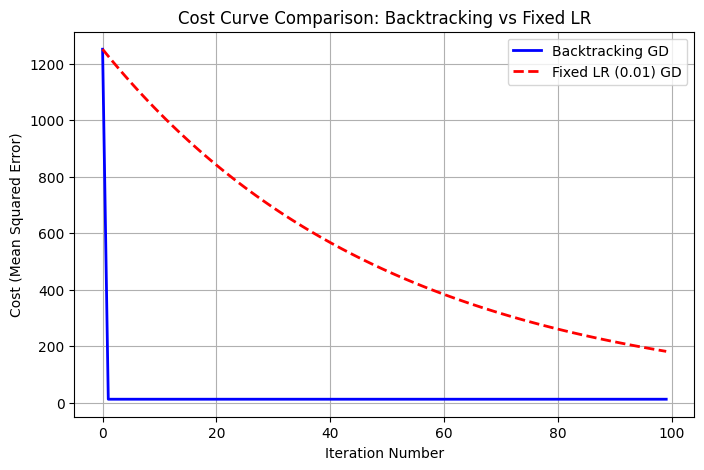

Final Cost - Backtracking GD: 12.9353
Final Cost - Fixed LR (0.01): 182.1924


In [5]:
def gradient_descent_fixed(X_features, y_target, alpha_fixed, iters):
    w = np.zeros(2)
    n_samples = len(y_target)
    costs = []

    for i in range(iters):
        y_pred = X_features.dot(w)
        error = y_pred - y_target
        cost = (1 / (2 * n_samples)) * np.sum(error ** 2)
        costs.append(cost)

        grad = (1 / n_samples) * X_features.T.dot(error)
        w = w - alpha_fixed * grad

    return w, costs

# Run Fixed LR (alpha = 0.01) on the original dataset (X_b, y)
w_fixed, costs_fixed = gradient_descent_fixed(X_b, y, alpha_fixed=0.01, iters=100)

# Plot Cost Curves
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), costs_history, label='Backtracking GD', color='blue', linewidth=2)
plt.plot(range(iterations), costs_fixed, label='Fixed LR (0.01) GD', color='red', linestyle='dashed', linewidth=2)

plt.title('Cost Curve Comparison: Backtracking vs Fixed LR')
plt.xlabel('Iteration Number')
plt.ylabel('Cost (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Cost - Backtracking GD: {costs_history[-1]:.4f}")
print(f"Final Cost - Fixed LR (0.01): {costs_fixed[-1]:.4f}")


Which method would you trust more in real-world ML?

I would trust Gradient Descent with Backtracking Line Search significantly more in a real-world machine learning scenario. A fixed learning rate is extremely rigid; if it is set too low (like 0.01 here), the model converges too slowly and wastes computational time, and if it is set too high, the model can overshoot the minimum and diverge completely. Backtracking Line Search automatically and dynamically tunes the step size at every iteration, ensuring guaranteed convergence and stability without the need for manual, trial-and-error hyperparameter tuning.